## DrugCentral. approval status for Ro5-passing compounds (not BBB filter, BBB is for ranking in future, want to keep the filter broad)

In [1]:
import pandas as pd
import requests
import time
from rdkit import Chem

BASE = "https://uxn2ycvimg.us-east-2.awsapprunner.com"

# load your Ro5-passing candidates
cands = pd.read_csv("jupyter_output/top_ro5_bbb_candidates.csv")

# keep only Ro5 passers, dedupe by compound
cands = cands[cands["rough_ro5_pass"] == True].drop_duplicates(subset=["gene","SMILES"]).copy()
print("Candidates to check:", len(cands))

Candidates to check: 75


In [2]:
# SMILES -> InChIKey (best match key for DrugCentral)
def smiles_to_inchikey(smiles):
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToInchiKey(mol)
    except Exception:
        return None

cands["inchikey"] = cands["SMILES"].apply(smiles_to_inchikey)

In [3]:
# Helper: GET wrapper
def dc_get(path):
    try:
        r = requests.get(f"{BASE}{path}", headers={"accept": "application/json"}, timeout=15)
        if r.status_code != 200:
            return None
        return r.json()
    except Exception:
        return None

# Match by InChIKey -> get struct_id, then pull ATC (approval signal)
def lookup_drugcentral(inchikey):
    if not inchikey:
        return {"dc_status": "no_inchikey"}

    hit = dc_get(f"/structures/inchikey/{inchikey}")
    if not hit:
        return {"dc_status": "not_in_drugcentral"}

    # hit may be a dict or list — normalize
    rec = hit[0] if isinstance(hit, list) else hit
    struct_id = rec.get("id") or rec.get("struct_id") or rec.get("cd_id")
    dc_name = rec.get("name")

    out = {
        "dc_status": "found",
        "dc_struct_id": struct_id,
        "dc_name": dc_name,
    }

    # ATC code = approved/marketed drug signal
    if struct_id:
        atc = dc_get(f"/struct2atc/struct_id/{struct_id}")
        if atc:
            atc_rec = atc[0] if isinstance(atc, list) else atc
            out["atc_code"] = atc_rec.get("atc_code")
            out["is_approved_drug"] = True
        else:
            out["is_approved_drug"] = False

    return out

In [4]:
# Run lookups
results = []
for i, row in enumerate(cands.itertuples(), start=1):
    print(f"{i}/{len(cands)} {row.compound}")
    info = lookup_drugcentral(row.inchikey)
    info["compound"] = row.compound
    info["SMILES"] = row.SMILES
    results.append(info)
    time.sleep(0.3)

dc_df = pd.DataFrame(results)
dc_df.head()

1/75 3-{2-[4-(6-Fluoro-benzo[d]isoxazol-3-yl)-piperidin-1-yl]-ethyl}-2-methyl-6,7,8,9-tetrahydro-pyrido[1,2-a]pyrimidin-4-one (Resperidone)
2/75 5-(4-Chloro-phenyl)-6-ethyl-pyrimidine-2,4-diamine
3/75 Chlorambucil
4/75 Cyclobenzaprine
5/75 Doxylamine
6/75 Estriol
7/75 Estrone
8/75 Finasteride
9/75 Haloperidol
10/75 Kinetin
11/75 Levofloxacin
12/75 Lisuride
13/75 Mianserin
14/75 Naltrexone
15/75 Naproxen
16/75 Primaquine
17/75 acebutolol
18/75 amitriptyline
19/75 benactyzine
20/75 diethylstilbestrol
21/75 pivampicillin
22/75 prednisolone
23/75 prednisone
24/75 spironolactone
25/75 tretinoin
26/75 3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dimethylpropan-1-amine
27/75 4-Amino-1-(5-hydroxymethyl-tetrahydro-furan-2-yl)-1H-pyrimidin-2-one
28/75 4-Amino-N-(2-diethylamino-ethyl)-benzamide
29/75 5-(4-Chloro-phenyl)-6-ethyl-pyrimidine-2,4-diamine
30/75 Acetohexamide
31/75 Benzocaine
32/75 Cinchocaine
33/75 Genistein
34/75 Glipizide
35/75 Haloperidol
36/75 Melatonin
37/75 Melperone
38/75 Nortript

,dc_status,compound,SMILES,dc_struct_id,dc_name,atc_code,is_approved_drug
0,not_in_drugcentral,3-{2-[4-(6-Fluoro-benzo[d]isoxazol-3-yl)-piper...,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC(CC3)C4=NOC5=C4C...,NaN,NaN,NaN,NaN
1,found,"5-(4-Chloro-phenyl)-6-ethyl-pyrimidine-2,4-dia...",CCC1=C(C(=NC(=N1)N)N)C2=CC=C(C=C2)Cl,2332.0,pyrimethamine,P01BD01,True
2,found,Chlorambucil,C1=CC(=CC=C1CCCC(=O)O)N(CCCl)CCCl,588.0,chlorambucil,L01AA02,True
3,found,Cyclobenzaprine,CN(C)CCC=C1C2=CC=CC=C2C=CC3=CC=CC=C31,751.0,cyclobenzaprine,M03BX08,True
4,found,Doxylamine,CC(C1=CC=CC=C1)(C2=CC=CC=N2)OCCN(C)C,962.0,doxylamine,R06AA09,True


In [5]:
# merge back and save
dc_df = dc_df.drop_duplicates(subset=["compound", "SMILES"])

final = cands.merge(dc_df, on=["compound", "SMILES"], how="left")
final.to_csv("jupyter_output/candidates_with_drugcentral.csv", index=False)
print("Saved: candidates_with_drugcentral.csv")
print(final["dc_status"].value_counts())

Saved: candidates_with_drugcentral.csv
dc_status
found                 62
not_in_drugcentral    13
Name: count, dtype: int64


### Cool figures

In [6]:
import matplotlib.pyplot as plt

#make sure approved column exists and is clean
final["approved"] = final["is_approved_drug"].fillna(False)

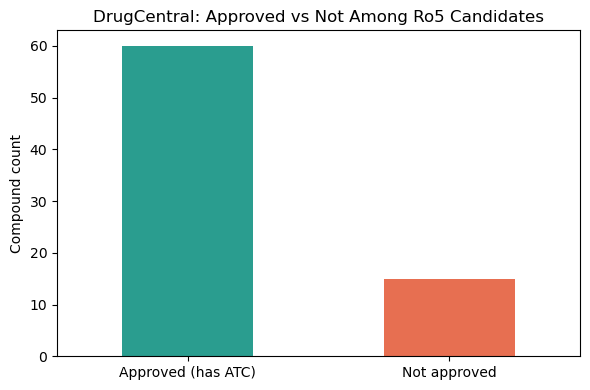

In [7]:
#chart 1: overall approved vs not approved
counts = final["approved"].value_counts()
counts.index = counts.index.map({True: "Approved (has ATC)", False: "Not approved"})

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["#2a9d8f", "#e76f51"])
plt.title("DrugCentral: Approved vs Not Among Ro5 Candidates")
plt.ylabel("Compound count")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

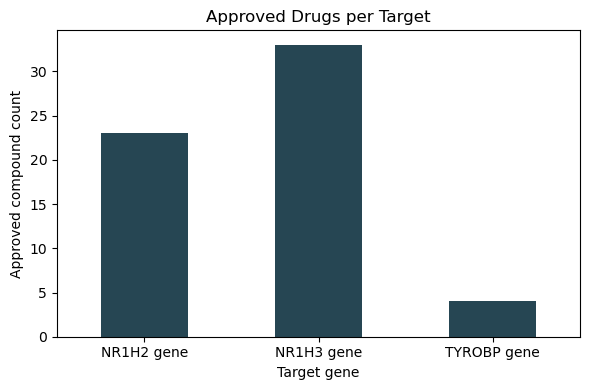

In [8]:
#chart 2: Approved drugs per gene/target
approved_by_gene = final.groupby("gene")["approved"].sum()

plt.figure(figsize=(6, 4))
approved_by_gene.plot(kind="bar", color="#264653")
plt.title("Approved Drugs per Target")
plt.ylabel("Approved compound count")
plt.xlabel("Target gene")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()